In [4]:
import pyarrow.dataset as ds

dataset = ds.dataset(
    "../output/illustris_skirt.parquet",
    format="parquet",
    exclude_invalid_files=True,
)
print(dataset.count_rows())
dataset.schema

376


image: list<element: list<element: list<element: float>>>
  child 0, element: list<element: list<element: float>>
      child 0, element: list<element: float>
          child 0, element: float
simulation: string
snapshot: int32
subhalo_id: int32
-- schema metadata --
huggingface: '{"info": {"features": {"image": {"feature": {"feature": {"f' + 259

In [5]:
df = dataset.to_table().to_pandas()

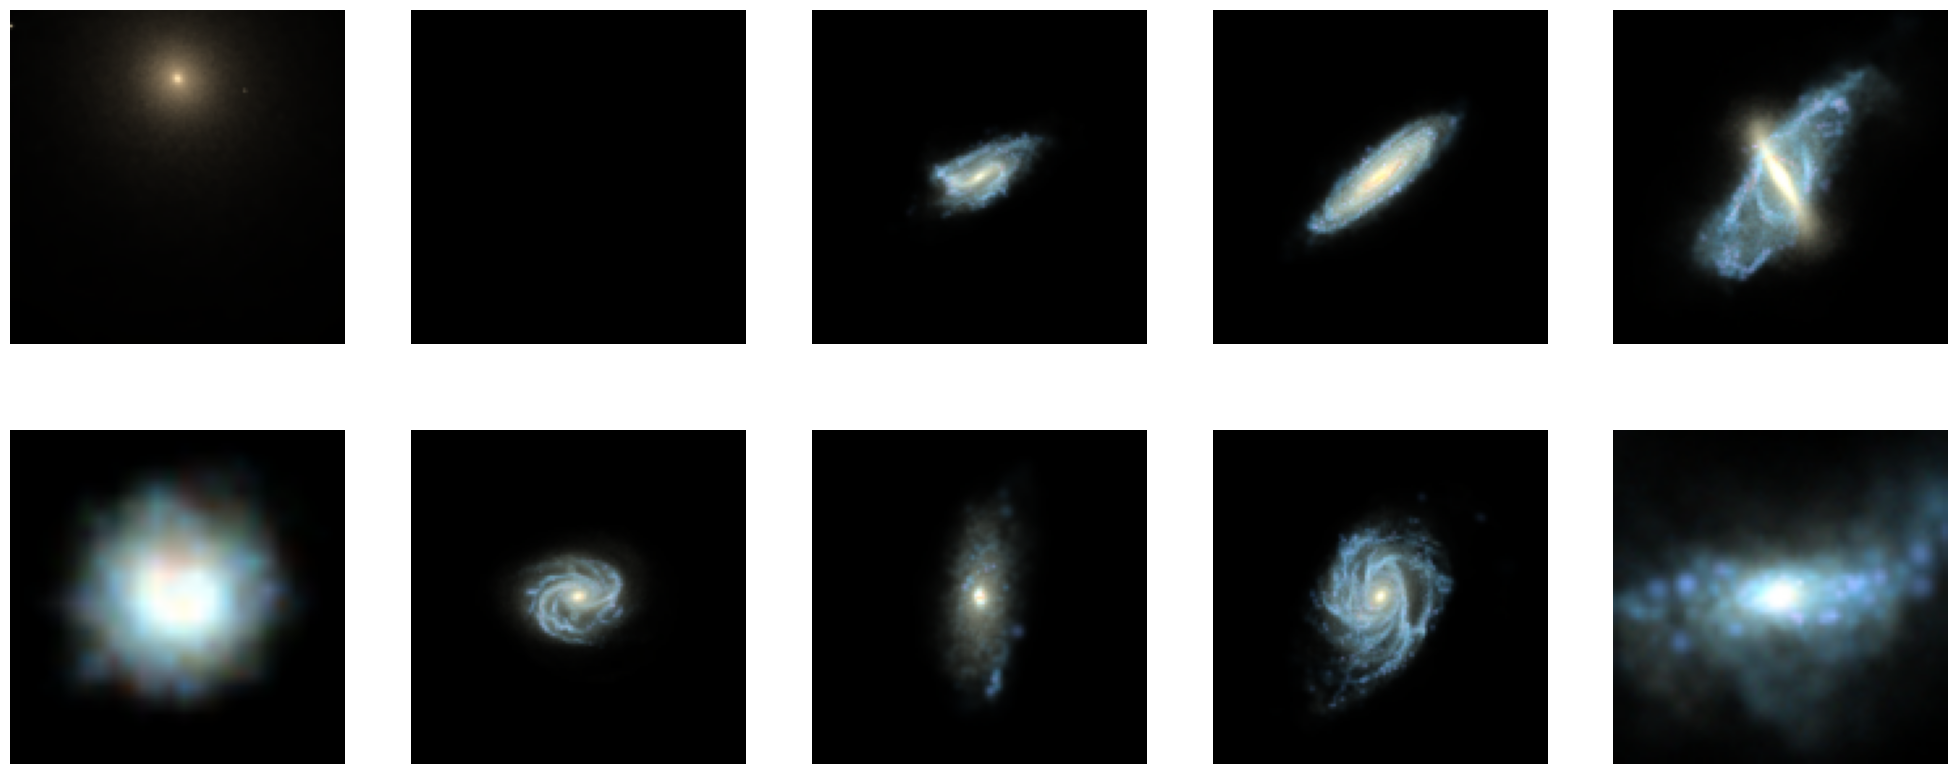

In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
for i, ax in enumerate(axes.flatten()):
    data = np.stack([np.stack(ch) for ch in df["image"][i]]).transpose(1, 2, 0) * 255
    image = Image.fromarray(data.astype(np.uint8), "RGB")
    ax.imshow(image)
    ax.axis("off")
plt.show()
